In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [23]:
df = pd.read_csv("student_gpa_performance_dataset.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (5000, 13)
   Student_ID  Study_Hours  Attendance  Previous_GPA  Assignments_Completed  \
0           1            7          86          6.41                      8   
1           2            4          75          5.44                      9   
2           3            8          84          4.91                      4   
3           4            5          83          7.79                      8   
4           5            7          84          6.83                     10   

   Class_Participation  Sleep_Hours  Internet_Usage  Extra_Activities  \
0                    6            6               6                 1   
1                    8            5               3                 0   
2                    9            8               6                 1   
3                    4            8               5                 0   
4                    2            7               6                 0   

   Stress_Level  Mock_Test_Score  Final_GPA Performance  
0         

In [24]:
# ==============================
# 3. DATA CLEANING
# ==============================

# Check null values

In [25]:
print(df.isnull().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)


Student_ID               0
Study_Hours              0
Attendance               0
Previous_GPA             0
Assignments_Completed    0
Class_Participation      0
Sleep_Hours              0
Internet_Usage           0
Extra_Activities         0
Stress_Level             0
Mock_Test_Score          0
Final_GPA                0
Performance              0
dtype: int64


In [26]:
# ==============================

# Study efficiency
df['Study_Efficiency'] = df['Study_Hours'] / (df['Internet_Usage'] + 1)

# Academic consistency
df['Academic_Consistency'] = (df['Previous_GPA'] + df['Mock_Test_Score']/10) / 2

# Health index
df['Health_Index'] = df['Sleep_Hours'] - df['Stress_Level']/2

In [27]:
# ==============================
# 5. ENCODING
# ==============================

le = LabelEncoder()
df['Performance'] = le.fit_transform(df['Performance'])


In [28]:
# ==============================
# 6. FEATURE SELECTION
# ==============================

X = df.drop(['Student_ID', 'Final_GPA', 'Performance'], axis=1)

y_gpa = df['Final_GPA']       # Regression target
y_perf = df['Performance']    # Classification target

In [29]:
# ==============================
# 7. SCALING (important for better performance)
# ==============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [30]:
# ==============================
# 8. TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_gpa_train, y_gpa_test = train_test_split(
    X_scaled, y_gpa, test_size=0.2, random_state=42
)

_, _, y_perf_train, y_perf_test = train_test_split(
    X_scaled, y_perf, test_size=0.2, random_state=42
)

In [31]:
# ==============================
# 9. MODEL TRAINING (REGRESSION)
# ==============================

reg_model = RandomForestRegressor(random_state=42)

# Hyperparameter tuning
param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_reg = GridSearchCV(reg_model, param_grid_reg, cv=3, n_jobs=-1)
grid_reg.fit(X_train, y_gpa_train)

best_reg = grid_reg.best_estimator_


In [34]:
# Prediction
y_pred_gpa = best_reg.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_gpa_test, y_pred_gpa))
r2 = r2_score(y_gpa_test, y_pred_gpa)

print("\n===== GPA MODEL =====")
print("Best Params:", grid_reg.best_params_)
print("RMSE:", rmse)
print("R2 Score:", r2)


===== GPA MODEL =====
Best Params: {'max_depth': None, 'n_estimators': 200}
RMSE: 0.19498272997883673
R2 Score: 0.9602534816529157


In [36]:
# ==============================
# 10. MODEL TRAINING (CLASSIFICATION)
# ==============================

clf_model = RandomForestClassifier(random_state=42)

param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_clf = GridSearchCV(clf_model, param_grid_clf, cv=3, n_jobs=-1)
grid_clf.fit(X_train, y_perf_train)

best_clf = grid_clf.best_estimator_

# Prediction
y_pred_perf = best_clf.predict(X_test)








In [37]:
# Evaluation
acc = accuracy_score(y_perf_test, y_pred_perf)

print("\n===== PERFORMANCE MODEL =====")
print("Best Params:", grid_clf.best_params_)
print("Accuracy:", acc)
print(classification_report(y_perf_test, y_pred_perf))


===== PERFORMANCE MODEL =====
Best Params: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.83
              precision    recall  f1-score   support

           0       0.78      0.87      0.83       355
           1       1.00      0.42      0.59        67
           2       0.84      0.91      0.88       425
           3       0.89      0.69      0.78       153

    accuracy                           0.83      1000
   macro avg       0.88      0.72      0.77      1000
weighted avg       0.84      0.83      0.82      1000



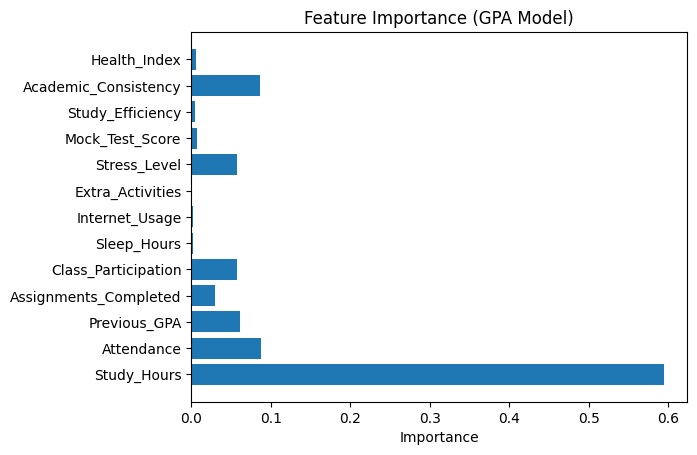

In [38]:
# ==============================
# 11. FEATURE IMPORTANCE (🔥 important)
# ==============================

import matplotlib.pyplot as plt

feature_importance = best_reg.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, feature_importance)
plt.title("Feature Importance (GPA Model)")
plt.xlabel("Importance")
plt.show()

In [39]:
# ==============================
# 12. TEST WITH NEW DATA
# ==============================

sample = np.array([[6, 85, 7.5, 9, 7, 7, 2, 1, 4, 80]])

# Apply same feature engineering
sample_df = pd.DataFrame(sample, columns=[
    "Study_Hours","Attendance","Previous_GPA","Assignments_Completed",
    "Class_Participation","Sleep_Hours","Internet_Usage",
    "Extra_Activities","Stress_Level","Mock_Test_Score"
])

sample_df['Study_Efficiency'] = sample_df['Study_Hours'] / (sample_df['Internet_Usage'] + 1)
sample_df['Academic_Consistency'] = (sample_df['Previous_GPA'] + sample_df['Mock_Test_Score']/10) / 2
sample_df['Health_Index'] = sample_df['Sleep_Hours'] - sample_df['Stress_Level']/2

sample_scaled = scaler.transform(sample_df)

gpa_pred = best_reg.predict(sample_scaled)
perf_pred = best_clf.predict(sample_scaled)

print("\n===== NEW STUDENT PREDICTION =====")
print("Predicted GPA:", gpa_pred[0])
print("Predicted Performance:", le.inverse_transform(perf_pred)[0])


===== NEW STUDENT PREDICTION =====
Predicted GPA: 8.251349999999993
Predicted Performance: Good
